In [70]:
#Groupmates: Regina Martinez, Lauren Nunez, Saam Grami

In [71]:
'''
Project Objective
Estimate the intrinsic and extrinsic parameters of the laptop camera, 
then verify those parameters by
comparing predicted object positions with manual 
measurements in both camera and world frames.

Slide 9 
    Intrinsic parameters - fx, fy, or, oc, Sx, Sy, and λ are known as the 
        intrinsic parameters which is related to the camera itself
    Extrinsic parameters - are another group of parameters, describing the relationship
        between the camera frame and the world frame in a 3D space
'''

'''
Preparation
1. Review the camera projection model together with intrinsic and extrinsic parameters.
2. Establish a right-hand-rule camera frame and world frame for the laptop setup.
3. Use a Python-based camera-calibration workflow to estimate the camera parameters
'''

'''
Verification Procedure
1. Keep the laptop and camera fixed throughout the verification process.
    So don't move laptop
2. Place an object of interest, such as a cup, on the table.
    Pick object
3. Capture an image of the object with the laptop camera.
    Use previous camera code
4. Manually determine the pixel coordinates of the object in the image.
    Not too sure how to do that other than having tick marks projected onto 
    the image to find the relative area
5. Manually measure the object's z coordinate with respect to the camera frame.
6. In Python, compute the object's x and y coordinates in the camera frame 
    using the camera projection model.
    Slide 
7. Use a coordinate transformation to compute the object's coordinates in the world frame.
8. Manually measure the object's world-frame coordinates and compare them with 
    the computed values.
9. Repeat the procedure for five different object locations.

'''

"\nVerification Procedure\n1. Keep the laptop and camera fixed throughout the verification process.\n    So don't move laptop\n2. Place an object of interest, such as a cup, on the table.\n    Pick object\n3. Capture an image of the object with the laptop camera.\n    Use previous camera code\n4. Manually determine the pixel coordinates of the object in the image.\n    Not too sure how to do that other than having tick marks projected onto \n    the image to find the relative area\n5. Manually measure the object's z coordinate with respect to the camera frame.\n6. In Python, compute the object's x and y coordinates in the camera frame \n    using the camera projection model.\n    Slide \n7. Use a coordinate transformation to compute the object's coordinates in the world frame.\n8. Manually measure the object's world-frame coordinates and compare them with \n    the computed values.\n9. Repeat the procedure for five different object locations.\n\n"

In [72]:

'''
Instrinsic - checkboard pictures, run open cv calibration, get k and distortion coeff
Extrinsic  - have checkerboard, pick one corner as world edges, take picture with board, 
    run solvePNP R and T values, do not move computer
Verification camera frame - place object in frame, take photo, find center of object, 
    record pixel, find object z val with ruler, use k and ruler val 
    to find x,y,z camera frame of object
World frame - apply r and t to camera frame coordinates, find objects world frame coords 
    with ruler, compute error between measured and calcualted
'''

'''
Pseudo code verification

Take camera frame
Run solve pnp and return R and t
Record the origin
Place object into view
Take new picture
Click on center of object 
(Insert) Record pixel 
(Insert) Manual measure object z value
Use camera matrix K to find objects x and y values
Combine x,y,z values into a coordinate
Calculate world frame from camera by applying R and t coordinates to camera frame
(Insert) Find objects world frame with a ruler
Compare the two world frame results

'''

'\nPseudo code verification\n\nTake camera frame\nRun solve pnp and return R and t\nRecord the origin\nPlace object into view\nTake new picture\nClick on center of object \n(Insert) Record pixel \n(Insert) Manual measure object z value\nUse camera matrix K to find objects x and y values\nCombine x,y,z values into a coordinate\nCalculate world frame from camera by applying R and t coordinates to camera frame\n(Insert) Find objects world frame with a ruler\nCompare the two world frame results\n\n'

In [82]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time


In [81]:


# Create folder to save images
os.makedirs('calibration_images', exist_ok=True)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open camera")
    exit()

num_images = 20
interval = 2  # seconds between each capture
images_taken = 0

print("Starting capture in 3 seconds... position your checkerboard!")
time.sleep(5)

while images_taken < num_images:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Countdown display on frame
    remaining = num_images - images_taken
    cv2.putText(frame, f'Photos taken: {images_taken}/{num_images}', 
                (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Next photo in {interval}s - move board to new angle!', 
                (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.imshow('Calibration Capture', frame)
    cv2.waitKey(2)

    # Save the image
    filename = f'calibration_images/calib_{images_taken:02d}.jpg'
    cv2.imwrite(filename, frame)
    print(f"Saved: {filename}")
    images_taken += 1

    # Wait interval, but keep showing live feed
    start = time.time()
    while time.time() - start < interval:
        ret, frame = cap.read()
        if ret:
            cv2.putText(frame, f'Photos taken: {images_taken}/{num_images}', 
                        (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(frame, f'Move board to new angle!', 
                        (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            cv2.imshow('Calibration Capture', frame)
            cv2.waitKey(1)

print("Done! All 20 images saved to calibration_images/")
cap.release()
cv2.destroyAllWindows()

Starting capture in 3 seconds... position your checkerboard!
Saved: calibration_images/calib_00.jpg
Saved: calibration_images/calib_01.jpg
Saved: calibration_images/calib_02.jpg
Saved: calibration_images/calib_03.jpg
Saved: calibration_images/calib_04.jpg
Saved: calibration_images/calib_05.jpg
Saved: calibration_images/calib_06.jpg
Saved: calibration_images/calib_07.jpg
Saved: calibration_images/calib_08.jpg
Saved: calibration_images/calib_09.jpg
Saved: calibration_images/calib_10.jpg
Saved: calibration_images/calib_11.jpg
Saved: calibration_images/calib_12.jpg
Saved: calibration_images/calib_13.jpg


KeyboardInterrupt: 

Camera matrix : 

[[583.23088027   0.         322.24514663]
 [  0.         584.2984019  239.48399101]
 [  0.           0.           1.        ]]
dist : 

[[-4.07901961e-02  5.51509138e-01 -2.00068962e-03 -1.14513599e-03
  -1.19089358e+00]]
rvecs : 

(array([[-0.03086461],
       [-0.1217823 ],
       [ 1.58219428]]), array([[-0.33804824],
       [-0.45560691],
       [ 1.52964377]]), array([[0.31361335],
       [0.20560427],
       [1.53261621]]), array([[ 0.22545686],
       [ 0.2810925 ],
       [-1.51855431]]), array([[ 0.3749141 ],
       [ 0.57447927],
       [-1.51627267]]), array([[ 0.43405477],
       [ 0.89488001],
       [-1.50201091]]), array([[-0.06189941],
       [ 0.40729529],
       [-1.52221161]]), array([[-0.41368558],
       [ 0.69377228],
       [ 1.61086284]]), array([[0.45479976],
       [0.43813116],
       [1.51767284]]), array([[0.49208171],
       [0.53234049],
       [1.48823831]]), array([[-0.3332824 ],
       [-0.31969017],
       [ 1.57272379]]), array([[-0

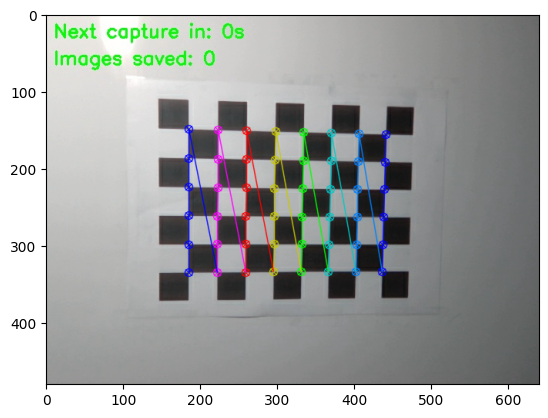

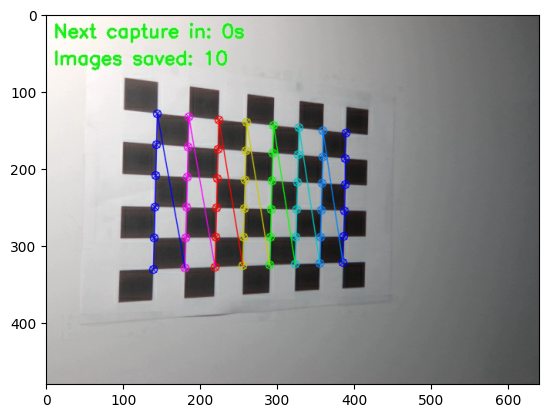

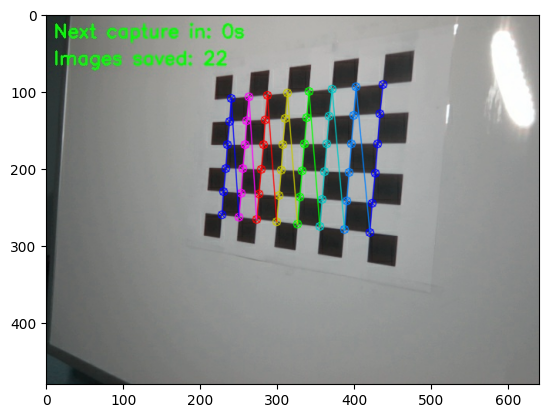

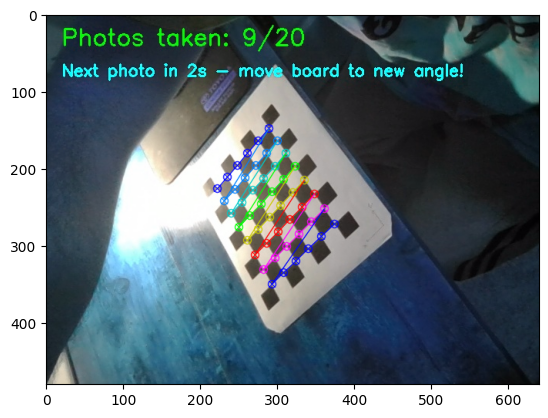

In [75]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 

 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)*2.2
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)
images = glob.glob('calibration_images/*.jpg')
counter = 0
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    cv2.imshow('img',img)
    #cv2.waitKey(0)
    
    
    if(counter%10 == 0 ):
        fig, ax = plt.subplots()
        ax.imshow(img)
    counter+=1
cv2.destroyAllWindows()
 
h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, k_mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(k_mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)
print("objpoints: ")
print(objpoints[0])#shows a total of 48 points



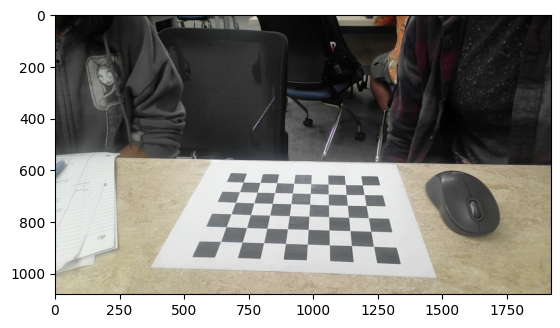

In [76]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)

img = mpimg.imread('test_frame.jpg')
fig, ax = plt.subplots()
ax.imshow(img)
#Notice how we can use cv2 or mpimg for printing the image? It may not look like it
#but it matters for the cell after this because it expects a certain arrangement of the data
#which it is wanting the cv2 arrangements
img = cv2.imread('test_frame.jpg')


Chess board corners found
Counter:  1
ret was equal to True
Origin pixel location (col, row): [641.2653 878.8455]
Camera matrix : 

[[583.23088027   0.         322.24514663]
 [  0.         584.2984019  239.48399101]
 [  0.           0.           1.        ]]
dist : 

[[-4.07901961e-02  5.51509138e-01 -2.00068962e-03 -1.14513599e-03
  -1.19089358e+00]]
rvecs : 

[[-2.36398861]
 [-0.22098326]
 [-0.99488972]]
tvecs : 

[[ 7.534785  ]
 [15.77288239]
 [20.77328246]]
Origin coordinates: 
 [641.2653 878.8455]


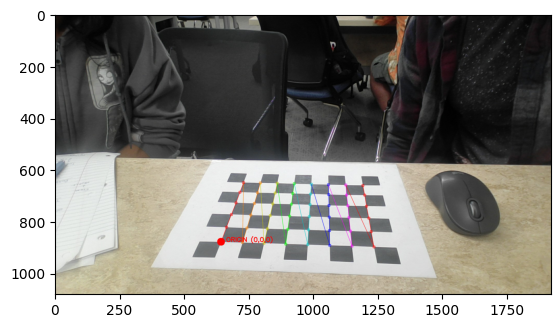

In [77]:

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# Find the chess board corners
# If desired number of corners are found in the image then ret = true
ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
print("Chess board corners found")
"""
If desired number of corner are detected,
we refine the pixel coordinates and display
them on the images of checker board
"""
counter=0
if ret == True:
    objpoints.append(objp)
    # refining pixel coordinates for given 2d points.
    corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
    
    imgpoints.append(corners2)

    # Draw and display the corners
    img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
    counter+=1
    print("Counter: ", counter)
print("ret was equal to True")

origin_pixel_coords = corners2[0][0]
print("Origin pixel location (col, row):", origin_pixel_coords)

img_origin = img.copy()
cv2.circle(img_origin, 
           (int(origin_pixel_coords[0]), int(origin_pixel_coords[1])), 
           radius=15, 
           color=(0, 0, 255),
           thickness=-1)
cv2.putText(img_origin, "ORIGIN (0,0,0)", 
            (int(origin_pixel_coords[0]) + 20, int(origin_pixel_coords[1])),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)



checkered_image = img_origin
fig, ax = plt.subplots()
#Shows the origin explicitly in the graph
ax.imshow(cv2.cvtColor(checkered_image, cv2.COLOR_BGR2RGB))
 
cv2.destroyAllWindows()
 
h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""

ret, world_frame_rvecs, world_frame_tvecs = cv2.solvePnP(
    objpoints[0].reshape(-1, 3),   # <-- fix shape from (1,48,3) to (48,3)
    imgpoints[0].reshape(-1, 1, 2), # <-- ensure correct shape
    k_mtx,
    dist
)
print("Camera matrix : \n")
print(k_mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(world_frame_rvecs)
print("tvecs : \n")
print(world_frame_tvecs)
print("Origin coordinates: \n", origin_pixel_coords)

#We now have the camera matrix, distortion coeff, t vecotr, R vector



In [78]:
#Gets u,v - the pixel coordinates of the object

#Reference: https://techvidvan.com/tutorials/displaying-the-coordinates-of-points-clicked-on-the-image-using-python-opencv/

#Loads image in a window and you can click on it to get the coordinate directly instead of using MS Paint

image = cv2.imread('test_frame.jpg')
#Resize to fit on screen
image = cv2.resize(image, (900, 600))
#Initializ u and v variables for pixel coordinates
u_coordinate = 0
v_coordinate = 0

def point_capture(event, x, y, flags, params):
    global u_coordinate, v_coordinate
    if event == cv2.EVENT_LBUTTONDOWN:
        #save clicked pixel
        u_coordinate = x
        v_coordinate = y
        print(f"Coordinate of Image: ({x}, {y})")
        cv2.putText(image, f'({x}, {y})', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        cv2.imshow('image', image)

cv2.imshow('image', image)
cv2.setMouseCallback('image', point_capture)
cv2.waitKey(0)
cv2.destroyAllWindows()

print("Saved: u=", u_coordinate, ", v=", v_coordinate)

Coordinate of Image: (739, 399)
Saved: u= 739 , v= 399


In [ ]:
#Getting the camera frame
#Loop through all 5 object pics
#Make sure pic files name match path and rename them to be in order 1-5 (ex: object1, object2,...)
for i in range (1, 6):
    image = cv2.imread('object' + str(i) + '.jpg')
    #Resize to fit on screen
    image = cv2.resize(image, (900, 600))
    #Initializ u and v variables for pixel coordinates
    u_coordinate = 0
    v_coordinate = 0

    #Reference: https://techvidvan.com/tutorials/displaying-the-coordinates-of-points-clicked-on-the-image-using-python-opencv/
    #Loads image in a window and you can click on it to get the coordinate directly instead of using MS Paint
    def point_capture(event, x, y, flags, params):
        global u_coordinate, v_coordinate
        if event == cv2.EVENT_LBUTTONDOWN:
            #save clicked pixel
            u_coordinate = x
            v_coordinate = y
            print(f"Coordinate of Image: ({x}, {y})")
            cv2.putText(image, f'({x}, {y})', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imshow('image', image)

    cv2.imshow('image', image)
    cv2.setMouseCallback('image', point_capture)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    print("Saved: u=", u_coordinate, ", v=", v_coordinate)



    # Getting the intrinsic values from the calibration 

    #focal length in x direction
    fx = k_mtx[0, 0]
    #Focal length in y direction
    fy = k_mtx[1, 1]
    #Image center x coordinate
    cx = k_mtx[0, 2]
    #Image center y coordinate
    cy = k_mtx[1, 2]

    #Pixel coordinates from cell above
    u_point = u_coordinate
    v_point = v_coordinate
    
    #Distance from camera to the object
    z_dist = 42.5

    #X distance from camera
    x_cam = -(u_point - cx) * (z_dist / fx)
    print("x:", x_cam)
    #Y distance from camera
    y_cam = -(v_point - cy) * (z_dist / fy)
    print("y:", y_cam)

    #Store camera frame for objects positions (xc, yc, zc)
    object_position_camera = (x_cam, y_cam, z_dist)
    print("Object position in camera:", object_position_camera)

    fig, ax = plt.subplots()
    ax.imshow(checkered_image)

    #Getting the world frame 
    '''
    World frame - apply r and t to camera frame coordinates, find objects world frame coords 
        with ruler, compute error between measured and calculated


    Calculate [xw, yw, zw] with respect to the world frame using these equations
        [xc yc zc]' = Rcw[xw yw zw]' + dcw
        [xw yw zw]' = Rcw^-1*([xc yc zc]'- dcw) 


    '''

    print("object_position_camera", object_position_camera)

    #import object camera coordinates
    obj_cam_coords = np.zeros((3, 1), dtype=np.float32)
    obj_cam_coords[0] = object_position_camera[0]
    obj_cam_coords[1] = object_position_camera[1]
    obj_cam_coords[2] = object_position_camera[2]
    print("obj_cam_coords \n",obj_cam_coords)

    #import R matrix
    world_frame_R, jacobian = cv2.Rodrigues(world_frame_rvecs)
    print("world_frame_R \n",world_frame_R)

    #create inverse R matrix
    wf_R_inv = np.linalg.inv(world_frame_R)
    print("wf inverse R matrix \n",wf_R_inv)

    #import t distances
    wf_t = world_frame_tvecs
    print("world_frame_t \n",wf_t)


    obj_wld_coords = wf_R_inv @ (obj_cam_coords - wf_t)
    print("object world coordinates: \n",obj_wld_coords)

    # Reverse check: R @ world_coords + t should give back camera coords
    recovered_cam = world_frame_R @ obj_wld_coords + wf_t
    print("Original camera coords: \n", obj_cam_coords)
    print("Recovered camera coords:\n", recovered_cam)
    print("Error:\n", obj_cam_coords - recovered_cam)
    

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'
